In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys
from tqdm import tqdm
import gc

# global_path = "/home/ids/edabier/HSU"
global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import plots
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.mod

Using device: cuda:0


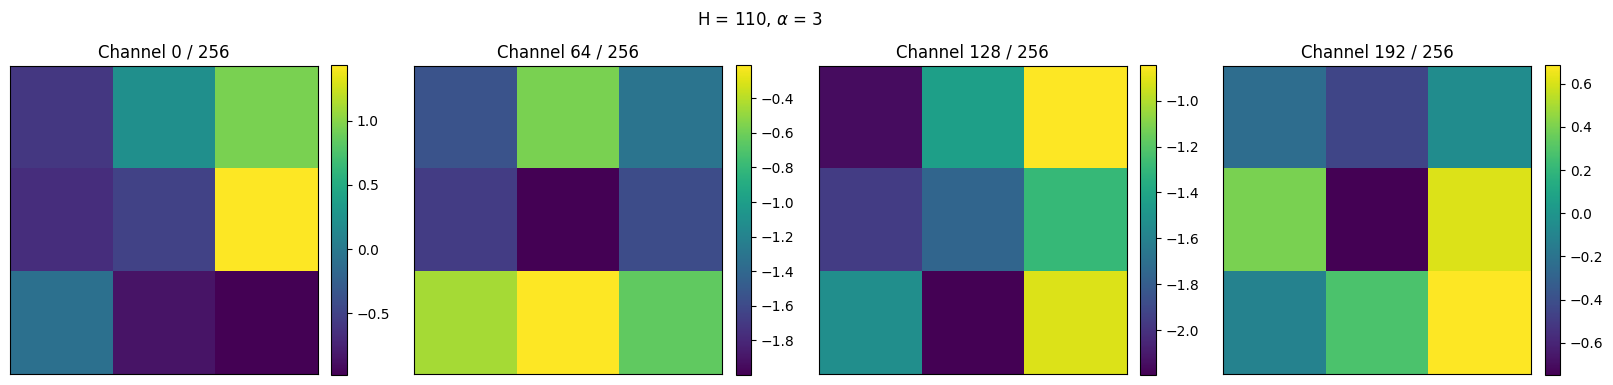

In [5]:
dataset = "apex"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm_name = "HyperFree"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
if fm_name == "DOFA":
    features = rsfm.get_dofa_features(fm, Y_init_f, wavelengths)
elif fm_name == "HyperFree":
    features = rsfm.get_hyperfree_features(fm, Y_init_f, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)
title = f"H = {new_H}, "
title += r"$\alpha$"
title += f" = {alpha}"
plots.plot_hsi(features.reshape(D, alpha, alpha), 4, title=title)

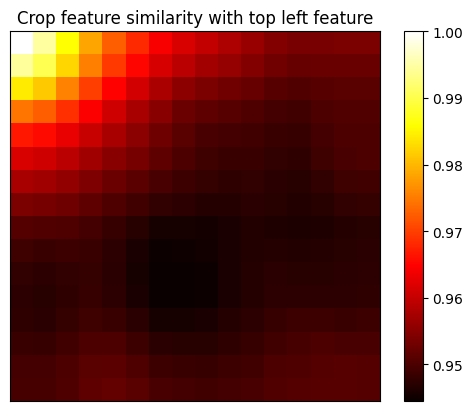

In [ ]:
# Compute similarity between crops' features

fm_name = "DOFA"
feature_maps = []

patch = 16

with torch.no_grad():
    for i in range(patch):
        for j in range(patch):
            Y_crop = Y_init[:, :, i:224+i, j:224+j]
            fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_crop, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)

            if fm_name == "DOFA":
                features = rsfm.get_dofa_features(fm, Y_init_f, wavelengths)
            elif fm_name == "HyperFree":
                features = rsfm.get_hyperfree_features(fm, Y_init_f, wavelengths)
            D = int(features.shape[0]/1)
            alpha = int(features.shape[1]**0.5)
            feature_maps.append(features.reshape(D, alpha, alpha))
            del features
            gc.collect()
            # Y_224, A_224 = rsfm.reshape_Y(fm_name, Y_init, new_H, A)

ref_feature = feature_maps[0]  # shape: (768, 14, 14)
ref_feature_flat = ref_feature.permute(1, 2, 0).reshape(-1, 768)  # shape: (196, 768)
similarity_map = torch.zeros((len(feature_maps), 14, 14))

for idx, feature in enumerate(feature_maps):
    feature_flat = feature.permute(1, 2, 0).reshape(-1, 768)  # shape: (196, 768)
    ref_norm = F.normalize(ref_feature_flat, p=2, dim=1)
    feature_norm = F.normalize(feature_flat, p=2, dim=1)
    cos_sim = F.cosine_similarity(ref_norm, feature_norm, dim=1)
    similarity_map[idx] = cos_sim.reshape(14, 14)

avg_similarity = similarity_map.mean(dim=(1, 2))
avg_similarity_map = avg_similarity.reshape(patch, patch)

plt.imshow(avg_similarity_map.detach().cpu(), cmap='hot')
plt.colorbar()
plt.title("Crop feature similarity with top left feature")
plt.xticks([])
plt.yticks([])
plt.show()

100%|██████████| 36/36 [05:16<00:00,  8.80s/it]


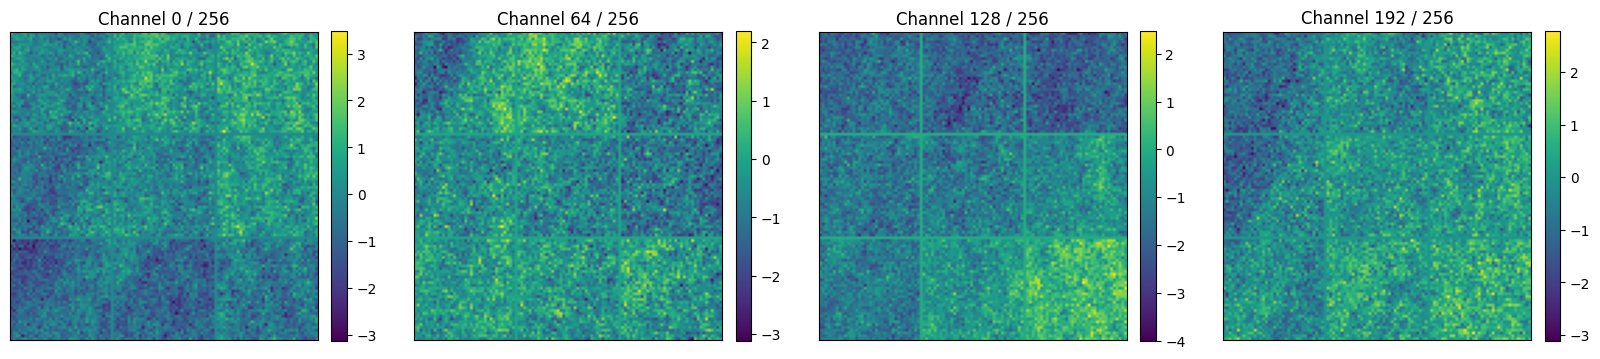

In [9]:
patch = 37
padding = patch//2
shift = 1
x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

Y_padded = F.pad(Y_init, pad=(padding, padding, padding, padding), mode="reflect")
feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

with torch.no_grad():
    for i in tqdm(range(0, 2*padding)):
        for j in range(0, 2*padding):

            n_crop = patch*(i//shift) + j//shift
            
            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)

            features = features.reshape(1, D, alpha, alpha)
            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()

# f2 = feature_map - feature_map.min()
# f2 /= f2.max()
plots.plot_hsi(feature_map, 4)#, rgb=True)

In [ ]:
patch = 16
padding = patch//2
shift = 1
x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

epochs, lr = 200, 0.002
optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

Y_padded = F.pad(Y_224, pad=(padding, padding, padding, padding), mode="reflect")
feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

with torch.no_grad():
    for i in tqdm(range(0, 2*padding)):
        for j in range(0, 2*padding):

            n_crop = patch*(i//shift) + j//shift
            
            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)

            features = features.reshape(1, D, alpha, alpha)
            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()

feature_map = (feature_map - feature_map.mean())/(1e-8 + feature_map.std())
# feature_map_resampled = F.grid_sample(feature_map, grid, mode='bilinear', padding_mode='reflection', align_corners=True)

n_xp = 10
sads, mses = [], []

for n in tqdm(range(n_xp)):

    model = rsfm.Unmixing_from_features2(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_224/Y_224.max(), c, is_unmixer=True, normalize=False)
    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        optimizer.zero_grad()
        E_hat, A_hat, Y_hat = model(feature_map)
        # E_hat, A_hat, Y_hat = model(feature_map_resampled)
        E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)
        A_hat = A_hat.unsqueeze(0)
        loss = model.loss(Y_224, Y_hat, A_hat, E_hat)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        
        del E_hat, A_hat

        # if epoch%(epochs//10)==0:
        #     print(f"Current epoch: {epoch}")

    model.eval()
    with torch.no_grad():    
        # E_hat, A_hat, Y_hat = model(feature_map_resampled)
        E_hat, A_hat, Y_hat = model(feature_map)
        E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)

        # E_hats[n] = E_hat
        # A_hats[n] = A_hat.squeeze(0)
        A_hat = A_hat.unsqueeze(0)
    sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_224, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    mses.append(mse)
# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)

# sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_224, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")